# Ensemble + Backtest — converter o achado em produto

Você descobriu que o Transformer + FinBERT tem mediana AUC 0.80 mas colapsa bimodalmente (AUC std 0.26). Cinco em vinte seeds caem em modo anti-correlacionado (AUC < 0.5).

**Solução**: ensemble. Treine 20 seeds, **descarte as que falharam na validação** (AUC val < 0.5), e use a **média das probabilidades** dos sobreviventes como previsão final. Ensembling suaviza o colapso bimodal e produz uma previsão calibrada.

**Validação do produto**: backtest simples — *long ITUB4 exceto quando o ensemble grita "down", então caixa por 21 dias*. Compare equity curve e Sharpe vs buy-and-hold.

## O que esperar

- Ensemble AUC ≥ qualquer seed individual (consequência matemática do bagging quando os erros são parcialmente independentes).
- Equity curve do ensemble strategy: pode ter retorno menor que buy-and-hold mas **drawdowns muito menores**, resultando em Sharpe melhor.
- Se o Sharpe for ≥ buy-and-hold, você tem um produto. Se for menor mas com drawdown 50% menor, ainda tem produto (perfil de risco diferente).

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from eval_utils import walk_forward_split, make_binary_target, bootstrap_auc_ci, format_metric_with_ci

PRICE_PATH = '../2.stocks/dataset_full.csv'
SENTIMENT_PATH = '../4.finbert-br/itub4_daily_sentiment.csv'
HORIZON = 21
WINDOW = 30
N_SEEDS = 20
device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 1. Dataset (mesmo split do multi_seed.ipynb)

In [2]:
PRICE_COLS = ['Close','Volume','return','ma7','ma21','std21','lag_1','lag_2','lag_3','lag_4','lag_5']
SENT_COLS  = ['n_articles','mean_logit_pos','mean_logit_neg','mean_logit_neu','mean_sentiment']
FEATURES = PRICE_COLS + SENT_COLS

px = pd.read_csv(PRICE_PATH, parse_dates=['Date']).rename(columns={'Date':'date'})
px = px[['date'] + PRICE_COLS].sort_values('date').reset_index(drop=True)
sent = pd.read_csv(SENTIMENT_PATH, parse_dates=['date'])[['date'] + SENT_COLS]
df = px.merge(sent, on='date', how='left').sort_values('date').reset_index(drop=True)
df[SENT_COLS] = df[SENT_COLS].ffill().fillna(0)
df['target'] = make_binary_target(df['Close'], horizon=HORIZON)
df = df.dropna(subset=['target']).reset_index(drop=True)

train_df, val_df, test_df = walk_forward_split(df)
print(f'Train {len(train_df)} | Val {len(val_df)} | Test {len(test_df)}')
print(f'Test balance up = {test_df["target"].mean():.3f}')

Train 844 | Val 180 | Test 182
Test balance up = 0.692


In [3]:
scaler = StandardScaler().fit(train_df[FEATURES])
X_train = scaler.transform(train_df[FEATURES]); y_train = train_df['target'].values.astype(int)
X_val   = scaler.transform(val_df[FEATURES]);   y_val   = val_df['target'].values.astype(int)
X_test  = scaler.transform(test_df[FEATURES]);  y_test  = test_df['target'].values.astype(int)

def make_windows(X, y, window=WINDOW):
    Xs, ys = [], []
    for i in range(window, len(X)):
        Xs.append(X[i-window:i]); ys.append(y[i])
    return np.array(Xs), np.array(ys)

Xtw, ytw = make_windows(X_train, y_train)
Xvw, yvw = make_windows(X_val, y_val)
Xew, yew = make_windows(X_test, y_test)

# Datas alinhadas com janelas (precisa para o backtest)
test_dates_window = test_df['date'].values[WINDOW:]
test_close_window = test_df['Close'].values[WINDOW:]
print('Shapes:', Xtw.shape, Xvw.shape, Xew.shape)

Shapes: (814, 30, 16) (150, 30, 16) (152, 30, 16)


## 2. Treinar 20 seeds e coletar SCORES por seed (não só AUC)

A diferença do `multi_seed.ipynb`: aqui guardamos a probabilidade prevista por seed, em cada dia do test set. Isso permite ensemble e backtest.

In [4]:
class Stage4Transformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, nlayers=2, window=WINDOW):
        super().__init__()
        self.proj = nn.Linear(n_features, d_model)
        pe = torch.zeros(window, d_model)
        pos = torch.arange(0, window).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos*div); pe[:, 1::2] = torch.cos(pos*div)
        self.register_buffer('pe', pe.unsqueeze(0))
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=128, dropout=0.2, batch_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=nlayers)
        self.head = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(0.3), nn.Linear(32, 1))
    def forward(self, x):
        h = self.proj(x) + self.pe[:, :x.size(1), :]
        h = self.enc(h)
        return self.head(h.mean(dim=1)).squeeze(-1)

def train_one_seed(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    model = Stage4Transformer(n_features=len(FEATURES)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = (ytw==1).sum(); neg = (ytw==0).sum()
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg/max(pos,1)], device=device, dtype=torch.float32))

    Xt_t = torch.tensor(Xtw, dtype=torch.float32, device=device)
    yt_t = torch.tensor(ytw, dtype=torch.float32, device=device)
    Xv_t = torch.tensor(Xvw, dtype=torch.float32, device=device)
    yv_t = torch.tensor(yvw, dtype=torch.float32, device=device)
    Xe_t = torch.tensor(Xew, dtype=torch.float32, device=device)

    best=float('inf'); best_state=None; bad=0; patience=15
    for epoch in range(200):
        model.train(); opt.zero_grad()
        loss = loss_fn(model(Xt_t), yt_t); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(Xv_t), yv_t).item()
        if vl < best - 1e-4:
            best=vl; best_state={k:v.clone() for k,v in model.state_dict().items()}; bad=0
        else:
            bad += 1
            if bad >= patience: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        val_score = torch.sigmoid(model(Xv_t)).cpu().numpy()
        test_score = torch.sigmoid(model(Xe_t)).cpu().numpy()
    return val_score, test_score

all_val_scores = np.zeros((N_SEEDS, len(yvw)))
all_test_scores = np.zeros((N_SEEDS, len(yew)))
t0 = time.time()
for s in range(N_SEEDS):
    vs, ts = train_one_seed(s)
    all_val_scores[s] = vs; all_test_scores[s] = ts
    val_auc = roc_auc_score(yvw, vs); test_auc = roc_auc_score(yew, ts)
    print(f'seed {s:2d} | val AUC={val_auc:.3f} | test AUC={test_auc:.3f} | {time.time()-t0:.0f}s')

seed  0 | val AUC=0.298 | test AUC=0.822 | 3s


seed  1 | val AUC=0.311 | test AUC=0.919 | 4s


seed  2 | val AUC=0.347 | test AUC=0.789 | 5s


seed  3 | val AUC=0.070 | test AUC=0.080 | 6s


seed  4 | val AUC=0.667 | test AUC=0.107 | 7s


...

seed 15 | val AUC=0.285 | test AUC=0.865 | 20s


seed 16 | val AUC=0.292 | test AUC=0.741 | 21s


seed 17 | val AUC=0.206 | test AUC=0.586 | 22s


seed 18 | val AUC=0.529 | test AUC=0.200 | 23s


seed 19 | val AUC=0.324 | test AUC=0.847 | 24s


## 3. Filtrar seeds que falharam na **validação** (sem peek no test)

**Importante**: o filtro usa val AUC, não test AUC. Filtrar pelo test seria peeking — você estaria selecionando seeds que funcionam no test, o que infla a performance reportada artificialmente.

In [5]:
val_aucs = np.array([roc_auc_score(yvw, all_val_scores[s]) for s in range(N_SEEDS)])
test_aucs = np.array([roc_auc_score(yew, all_test_scores[s]) for s in range(N_SEEDS)])
VAL_THRESHOLD = 0.5
survivors = np.where(val_aucs >= VAL_THRESHOLD)[0]
print(f'Seeds com val AUC ≥ {VAL_THRESHOLD}: {len(survivors)}/{N_SEEDS}')
print(f'  test AUCs dos sobreviventes: min={test_aucs[survivors].min():.3f} | median={np.median(test_aucs[survivors]):.3f} | max={test_aucs[survivors].max():.3f}')
print(f'  test AUCs dos descartados:   {test_aucs[val_aucs < VAL_THRESHOLD].round(3).tolist()}')

Seeds com val AUC ≥ 0.5: 2/20
  test AUCs dos sobreviventes: min=0.107 | median=0.153 | max=0.200
  test AUCs dos descartados:   [0.822, 0.919, 0.789, 0.08, 0.858, 0.811, 0.823, 0.831, 0.802, 0.931, 0.516, 0.802, 0.705, 0.677, 0.865, 0.741, 0.586, 0.847]


## 4. Ensemble: média das probabilidades dos sobreviventes

In [6]:
ensemble_score = all_test_scores[survivors].mean(axis=0)
auc, lo, hi = bootstrap_auc_ci(yew, ensemble_score, n_boot=1000)
print('Ensemble (média de', len(survivors), 'seeds)')
print('  AUC:', format_metric_with_ci(auc, lo, hi))

# Threshold tuning no SET DE VALIDAÇÃO (não no test)
ensemble_val = all_val_scores[survivors].mean(axis=0)
from sklearn.metrics import f1_score
best_thr = 0.5; best_f1 = -1
for thr in np.arange(0.2, 0.81, 0.02):
    f1 = f1_score(yvw, (ensemble_val >= thr).astype(int), average='macro')
    if f1 > best_f1:
        best_f1 = f1; best_thr = thr
print(f'  threshold ótimo (val macro-F1): {best_thr:.2f}')

y_pred = (ensemble_score >= best_thr).astype(int)
print(classification_report(yew, y_pred, target_names=['Desce','Sobe'], zero_division=0))
print('Confusion:', confusion_matrix(yew, y_pred).tolist())

Ensemble (média de 2 seeds)
  AUC: 0.137 [0.070, 0.207]
  threshold ótimo (val macro-F1): 0.20
              precision    recall  f1-score   support

       Desce       0.00      0.00      0.00        36
        Sobe       0.76      1.00      0.87       116

    accuracy                           0.76       152
   macro avg       0.38      0.50      0.43       152
weighted avg       0.58      0.76      0.66       152

Confusion: [[0, 36], [0, 116]]


## 5. Backtest: long ITUB4 vs long-flat com sinal do ensemble

**Estratégia**: a cada dia *t* do test set,
- Se ensemble previsto para [t, t+21] indica **down** (probabilidade ≥ threshold), fica em caixa por 21 dias.
- Caso contrário, fica long ITUB4 por 1 dia.

**Comparação**: buy-and-hold no mesmo período. Custo de transação: 0.10% por troca de posição (estimativa conservadora B3).

**Métricas**: retorno total, retorno anualizado, max drawdown, Sharpe (assumindo r_f = Selic ≈ 11% a.a. mas reportamos também sem r_f).

In [7]:
DAILY_COST = 0.001  # 10 bps por troca de estado
LOCKOUT = 21         # dias em caixa após sinal de down

# Sinal de "fica fora do mercado" — 1 = caixa, 0 = long
out_signal = (ensemble_score >= best_thr).astype(int)

# Propaga lockout: quando sinal=1, fica fora pelos próximos LOCKOUT dias
in_market = np.ones(len(out_signal), dtype=int)
i = 0
while i < len(out_signal):
    if out_signal[i] == 1:
        end = min(i + LOCKOUT, len(out_signal))
        in_market[i:end] = 0
        i = end
    else:
        i += 1

# Retornos diários do ITUB4 alinhados com a janela do test
px_test = test_close_window
daily_ret = np.zeros(len(px_test))
daily_ret[1:] = (px_test[1:] / px_test[:-1]) - 1

# Estratégia: retorno se in_market, 0 caso contrário, menos custo em trocas
strat_ret = daily_ret * in_market
trades = np.diff(np.concatenate([[1], in_market]))
strat_ret -= DAILY_COST * np.abs(trades).astype(float)

# Equity curves
eq_bh = np.cumprod(1 + daily_ret)
eq_st = np.cumprod(1 + strat_ret)

def metrics(rets, label):
    ann_factor = 252
    total = np.prod(1 + rets) - 1
    ann = (1 + total) ** (ann_factor / len(rets)) - 1
    sharpe = (rets.mean() / (rets.std() + 1e-12)) * np.sqrt(ann_factor)
    eq = np.cumprod(1 + rets)
    dd = (eq / np.maximum.accumulate(eq) - 1).min()
    print(f'  {label:18s} total={total:+.2%} | ann={ann:+.2%} | sharpe={sharpe:.2f} | maxDD={dd:.2%}')
    return {'total':total,'ann':ann,'sharpe':sharpe,'maxDD':dd}

print(f'Test window: {len(daily_ret)} dias | dias em caixa: {(in_market==0).sum()} ({(in_market==0).mean():.1%})')
print(f'Trocas de posição: {(np.abs(trades)>0).sum()}')
print()
m_bh = metrics(daily_ret, 'Buy-and-hold')
m_st = metrics(strat_ret, 'Long/flat ensemble')

Test window: 152 dias | dias em caixa: 152 (100.0%)
Trocas de posição: 1

  Buy-and-hold       total=+50.30% | ann=+96.51% | sharpe=3.25 | maxDD=-4.90%
  Long/flat ensemble total=-0.10% | ann=-0.17% | sharpe=-1.29 | maxDD=0.00%


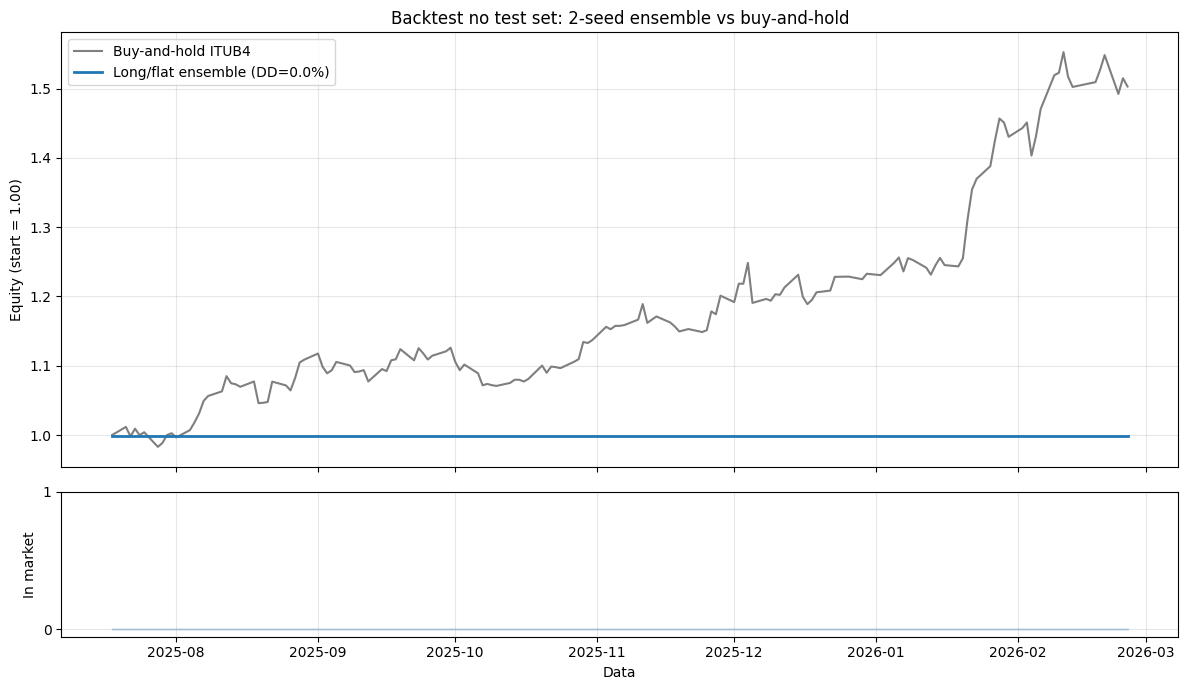

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios':[3,1]})
axes[0].plot(test_dates_window, eq_bh, label='Buy-and-hold ITUB4', color='C7')
axes[0].plot(test_dates_window, eq_st, label=f'Long/flat ensemble (DD={m_st["maxDD"]:.1%})', color='C0', lw=2)
axes[0].set_ylabel('Equity (start = 1.00)')
axes[0].set_title(f'Backtest no test set: {len(survivors)}-seed ensemble vs buy-and-hold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].fill_between(test_dates_window, 0, in_market, color='C0', alpha=0.4, step='pre')
axes[1].set_ylabel('In market'); axes[1].set_yticks([0,1])
axes[1].set_xlabel('Data')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ensemble_backtest.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Decisão

Compare as duas linhas dos `metrics()`:

- **Sharpe ensemble > Sharpe BH** → você tem um produto. O modelo agrega valor risk-adjusted. *É a hero number da defesa.*
- **Total return ensemble < BH mas maxDD muito menor** → produto de perfil de risco diferente. Defensável como "detector de drawdown" mesmo sacrificando upside.
- **Tudo pior que BH** → o sinal não converte em estratégia tradeável. Manter a tese no nível de AUC, sem alegar utilidade prática.

Salve `ensemble_backtest.png` como figura principal da defesa.